In [1]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


# 1. SETUP

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

# 2. CONFIG

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # Sesuaikan kemampuan GPU

TRAIN_DIR = "data/processed/train"
VAL_DIR   = "data/processed/validation"
TEST_DIR  = "data/processed/test"

EPOCHS = 30 # Bisa diubah 
FINE_TUNE_EPOCHS = 15 # Epoch untuk fine-tuning

INITIAL_LR = 1e-4 # Learning rate di 0.0001
FINE_TUNE_LR = 1e-5 # Learning rate di 0.00001 untuk fine-tuning

# 3. LOAD DATASET

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data generator tanpa rescale agar preprocessing dilakukan khusus di model
train_gen = ImageDataGenerator()
val_test_gen = ImageDataGenerator()

# Membuat generator untuk data train
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Membuat generator untuk data validasi
val_data = val_test_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Membuat generator untuk data test
test_data = val_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1230 images belonging to 4 classes.
Found 132 images belonging to 4 classes.
Found 133 images belonging to 4 classes.


# 4. CALLBACK

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Menerapkan early stopping jika tidak ada peningkatan dalam 7 epoch
callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True),
    ModelCheckpoint("models/best_model.h5", save_best_only=True) # 
]

# 5. FUNCTION EVALUASI

In [6]:
def evaluate_model(model, name):
    print(f"\n=== {name} ===")
    # Evaluasi model pada data test
    loss, acc = model.evaluate(test_data)
    print("Accuracy:", acc)
    print("Loss:", loss)
    # Prediksi label untuk data test
    y_pred = np.argmax(model.predict(test_data), axis=1)
    y_true = test_data.classes
    # Tampilkan classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=test_data.class_indices.keys()))
    # Tampilkan confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    
    return acc

# 6. MODEL

## A. MobileNetV2

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Membangun MobileNetV2 sebagai base model
def build_mobilenet():
    input_layer = tf.keras.Input(shape=(224, 224, 3))
    x = layers.Lambda(lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t))(input_layer)

    base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base

## B. EfficientNetB0

In [8]:
from tensorflow.keras.applications import EfficientNetB0

# Membangun EfficientNetB0 sebagai base model
def build_efficientnet():
    input_layer = tf.keras.Input(shape=(224, 224, 3))
    x = layers.Lambda(lambda t: t * 255.0)(input_layer)

    base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base

## C. Hybrid (Feature Fusion)

In [9]:
def build_fusion():
    input_layer = tf.keras.Input(shape=(224, 224, 3))

    mob_in = layers.Lambda(lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t))(input_layer)
    eff_in = layers.Lambda(lambda t: t * 255.0)(input_layer)

    base1 = MobileNetV2(weights='imagenet', include_top=False, input_tensor=mob_in)
    base2 = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=eff_in)

    base1.trainable = False
    base2.trainable = False

    x1 = layers.GlobalAveragePooling2D()(base1.output)
    x1 = layers.BatchNormalization()(x1)

    x2 = layers.GlobalAveragePooling2D()(base2.output)
    x2 = layers.BatchNormalization()(x2)

    fusion = layers.concatenate([x1, x2])

    x = layers.Dense(256, activation='relu')(fusion)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=input_layer, outputs=output)
    return model, base1, base2

# 7. Training Function (2 Tahap)

In [10]:
def train_model(model, base_model=None):
    # Tahap 1
    model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        callbacks=callbacks
    )

    # Tahap 2 (Fine-tuning)
    if base_model is not None:
        base_model.trainable = True
        for layer in base_model.layers[:-80]:
            layer.trainable = False
        for layer in base_model.layers[-80:]:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_data,
        validation_data=val_data,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=callbacks
    )

    return model

# 8. Train & Evaluasi Model

## A. MobileNetV2

C:\Users\rifqi\AppData\Local\Temp\ipykernel_9972\1700337301.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)


Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.2739 - loss: 2.2020

39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 315ms/step - accuracy: 0.3016 - loss: 2.0491 - val_accuracy: 0.3864 - val_loss: 1.3790
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.4207 - loss: 1.5253

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 275ms/step - accuracy: 0.4512 - loss: 1.4847 - val_accuracy: 0.5227 - val_loss: 1.1383
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.5240 - loss: 1.3012

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 272ms/step - accuracy: 0.5325 - loss: 1.2718 - val_accuracy: 0.5682 - val_loss: 0.9846
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.5729 - loss: 1.0756

...

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 267ms/step - accuracy: 0.8813 - loss: 0.3165 - val_accuracy: 0.7955 - val_loss: 0.5266
Epoch 23/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 259ms/step - accuracy: 0.8951 - loss: 0.2786 - val_accuracy: 0.7955 - val_loss: 0.5293
Epoch 24/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9139 - loss: 0.2735

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step - accuracy: 0.9106 - loss: 0.2718 - val_accuracy: 0.8030 - val_loss: 0.5167
Epoch 25/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9052 - loss: 0.2589

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step - accuracy: 0.9065 - loss: 0.2613 - val_accuracy: 0.8030 - val_loss: 0.5082
Epoch 26/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9317 - loss: 0.2380

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step - accuracy: 0.9220 - loss: 0.2441 - val_accuracy: 0.8182 - val_loss: 0.4995
Epoch 27/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - accuracy: 0.9033 - loss: 0.2535 - val_accuracy: 0.8182 - val_loss: 0.5011
Epoch 28/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9371 - loss: 0.2224

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 269ms/step - accuracy: 0.9211 - loss: 0.2457 - val_accuracy: 0.8258 - val_loss: 0.4972
Epoch 29/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.9244 - loss: 0.2283 - val_accuracy: 0.8106 - val_loss: 0.4987
Epoch 30/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.9228 - loss: 0.2359 - val_accuracy: 0.8258 - val_loss: 0.4977
Epoch 1/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 33s 510ms/step - accuracy: 0.6195 - loss: 1.0435 - val_accuracy: 0.7955 - val_loss: 0.5302
Epoch 2/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 466ms/step - accuracy: 0.6846 - loss: 0.8361 - val_accuracy: 0.7500 - val_loss: 0.6182
Epoch 3/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 468ms/step - accuracy: 0.7415 - loss: 0.7175 - val_accuracy: 0.7273 - val_loss: 0.7050
Epoch 4/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 476ms/step - accuracy: 0.7675 - loss: 0.6308 - val_accuracy: 0.7197 - val_loss: 0.7906
Epoch 5/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 486ms/step - accuracy: 0.8000 - loss: 0.5096 - val_accuracy: 0.7

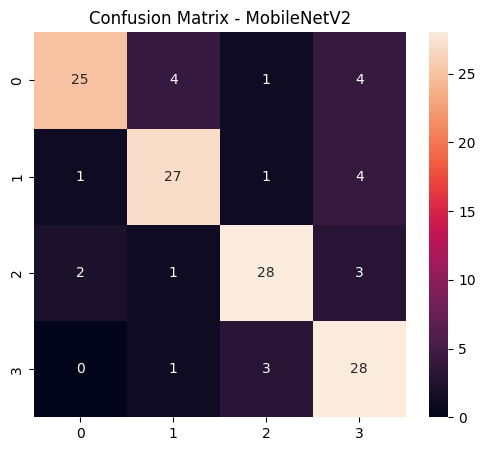

In [11]:
model_m, base_m = build_mobilenet()
model_m = train_model(model_m, base_m)
acc_m = evaluate_model(model_m, "MobileNetV2")

## B. EfficientNetB0

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 24s 403ms/step - accuracy: 0.2512 - loss: 2.1671 - val_accuracy: 0.2652 - val_loss: 1.8512
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 339ms/step - accuracy: 0.2683 - loss: 2.0561 - val_accuracy: 0.2576 - val_loss: 1.6274
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 355ms/step - accuracy: 0.2756 - loss: 1.9102 - val_accuracy: 0.2500 - val_loss: 1.5910
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 343ms/step - accuracy: 0.2724 - loss: 1.8686 - val_accuracy: 0.2424 - val_loss: 1.5965
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 342ms/step - accuracy: 0.3041 - loss: 1.8470 - val_accuracy: 0.2424 - val_loss: 1.5747
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 345ms/step - accuracy: 0.2805 - loss: 1.7904 - val_accuracy: 0.1970 - val_loss: 1.5884
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 347ms/step - accuracy: 0.2764 - loss: 1.8762 - val_accuracy: 0.2424 - val_loss: 1.5653
Epoch 1/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 39s 595ms/step - accuracy: 0.2577 - loss: 2.2523 - val_accu

d:\Kuliah\SKRIPSI\MODEL\venv_skripsi\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Kuliah\SKRIPSI\MODEL\venv_skripsi\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Kuliah\SKRIPSI\MODEL\venv_skripsi\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

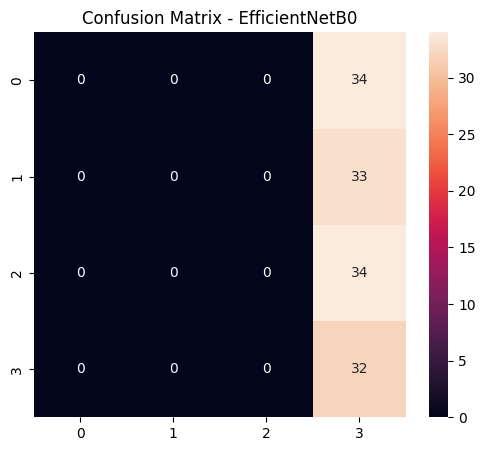

In [12]:
model_e, base_e = build_efficientnet()
model_e = train_model(model_e, base_e)
acc_e = evaluate_model(model_e, "EfficientNetB0")

## C. Hybrid Model

In [13]:
model_f, base1, base2 = build_fusion()

# fine-tune dua backbone
model_f.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_f.fit(train_data, validation_data=val_data, epochs=EPOCHS, callbacks=callbacks)

for layer in base1.layers[-30:]:
    layer.trainable = True
for layer in base2.layers[-30:]:
    layer.trainable = True

model_f.compile(
    optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_f.fit(train_data, validation_data=val_data, epochs=FINE_TUNE_EPOCHS, callbacks=callbacks)

acc_f = evaluate_model(model_f, "Fusion Model")

C:\Users\rifqi\AppData\Local\Temp\ipykernel_9972\2556028073.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base1 = MobileNetV2(weights='imagenet', include_top=False, input_tensor=mob_in)


Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 38s 684ms/step - accuracy: 0.3512 - loss: 1.8607 - val_accuracy: 0.5227 - val_loss: 1.3588
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 582ms/step - accuracy: 0.5106 - loss: 1.3679 - val_accuracy: 0.6515 - val_loss: 1.0459
Epoch 3/30
13/39 ━━━━━━━━━━━━━━━━━━━━ 13s 530ms/step - accuracy: 0.6510 - loss: 1.0705

KeyboardInterrupt: 

# 9. Perbandingan Hasil

In [14]:
print("\n=== HASIL AKHIR ===")
print(f"MobileNetV2   : {acc_m}")
print(f"EfficientNet  : {acc_e}")
print(f"Fusion Model  : {acc_f}")


=== HASIL AKHIR ===
MobileNetV2   : 0.8120300769805908
EfficientNet  : 0.24060150980949402


NameError: name 'acc_f' is not defined